# Employee Attrition Prediction using Machine Learning
## Task 1: Data Loading & Exploration
In this task, the dataset is loaded using Pandas. The first few records are examined
to understand the structure of the dataset. The dimensions, column names, data types, 
and missing values are checked to gain an initial understanding of the data before preprocessing.

In [3]:
import pandas as pd
df=pd.read_csv(r"C:\Users\DELL\AppData\Local\Temp\867448f4-ecec-498f-a71a-a89938b2e135_archive (2).zip.135\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Dataset Shape

The shape of the dataset helps identify the total number of observations (rows) and features (columns) available for analysis.

In [4]:
df.shape

(1470, 35)

### Column Information

The column names and data types are inspected to identify numerical and categorical variables.

### Target Variable and Features
The target variable for prediction is **Attrition**, while all remaining columns act as input features.

In [5]:
y=df["Attrition"]
X=df.drop('Attrition',axis=1)
X 

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,...,3,80,1,17,3,3,5,2,0,3
1466,39,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,...,1,80,1,9,5,3,7,7,1,7
1467,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,...,4,80,0,17,3,2,9,6,0,8


In [6]:
y

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: object

In [7]:
print("\nTarget Variable:")
print(df["Attrition"].value_counts())


Target Variable:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [8]:
attrition_rate = (df["Attrition"].value_counts()["Yes"] / len(df))*100
print(f"\nAttrition Rate: {attrition_rate:.2f}%")


Attrition Rate: 16.12%


### Number Of Numeric and Categorical Columns

In [9]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


### Observation:
The dataset is imbalanced because employees who stayed are significantly more than employees who left. This means special care must be taken while training models.

## Task 2: Data Cleaning

Data cleaning is performed to improve the quality of the dataset. Duplicate records are removed, missing values are handled, and categorical features are converted into numerical format for machine learning algorithms.

In [10]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Missing Value Analysis

Before training machine learning models, it is essential to identify missing values.
Missing values can:
- Reduce model accuracy
- Introduce bias
- Cause errors during training
The output shows that there are no missing values in any row or column.
If missing values are present, they should be handled using appropriate imputation techniques.

In [11]:
drop_cols = ['EmployeeNumber','Over18','StandardHours','EmployeeCount']
df.drop(columns=drop_cols, inplace=True)

### Removing Irrelevant Features
Several columns do not contribute useful information for prediction:
#### EmployeeNumber
A unique identifier that does not influence employee behavior.
#### Over18
Contains the same value for every employee.
#### StandardHours
Contains a constant value for all employees.
#### EmployeeCount
Contains only one repeated value.
Such columns increase complexity without improving model performance and are therefore removed.

In [12]:
df["Attrition"] = df["Attrition"].map({"Yes":1,"No":0})

### Target Variable Encoding

Machine learning models require numerical values.

The Attrition column is converted as follows:

- Yes → 1
- No → 0

Where:

- 1 indicates employee attrition
- 0 indicates employee retention

This transformation enables classification algorithms to learn patterns associated with employee turnover.

In [74]:
from sklearn.preprocessing import StandardScaler
X_original = df.drop("Attrition", axis=1)
X_encoded = pd.get_dummies(X_original, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

### One-Hot Encoding

Most machine learning algorithms cannot process text values directly.

One-Hot Encoding converts categorical variables into binary numerical columns.

This transformation preserves category information while making the data suitable for machine learning.

### Feature Scaling

Different features may have vastly different numerical ranges.

Without scaling, larger values can dominate model learning.

StandardScaler transforms features so that:

- Mean = 0
- Standard Deviation = 1

This ensures fair contribution from all variables.

## Task 3: Exploratory Data Analysis

# Exploratory Data Analysis (EDA)

EDA helps us understand employee behavior patterns and identify factors associated with attrition.

The objective is to discover actionable insights before building predictive models.

## 1. Attrition Rate by Department

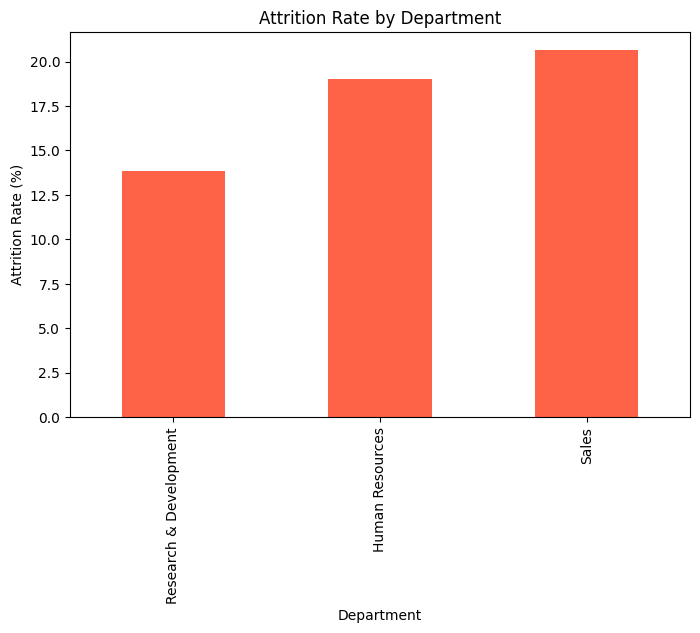

In [50]:
import matplotlib.pyplot as plt
department_attrition = pd.crosstab(df['Department'],df['Attrition'],normalize='index') * 100
department_attrition[1].sort_values().plot(kind='bar',color='tomato',figsize=(8,5))
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.show()

### Observation

- The **Sales** department has the **highest attrition rate (approximately 20.6%)**, indicating that employees in this department are more likely to leave the organization than those in other departments.
- The **Human Resources** department records the **second-highest attrition rate (approximately 19%)**, suggesting a relatively high level of employee turnover.

- The **Research & Development** department has the **lowest attrition rate (approximately 13.8%)**, indicating better employee retention compared to the other departments.

- The difference in attrition rates suggests that employee turnover varies significantly across departments, with customer-facing and operational departments experiencing greater workforce instability.

- These findings indicate that the **Sales** and **Human Resources** departments should be prioritized for employee retention initiatives, such as improving job satisfaction, career development opportunities, and employee engagement programs.

## 2. Attrition Rate by Job Role

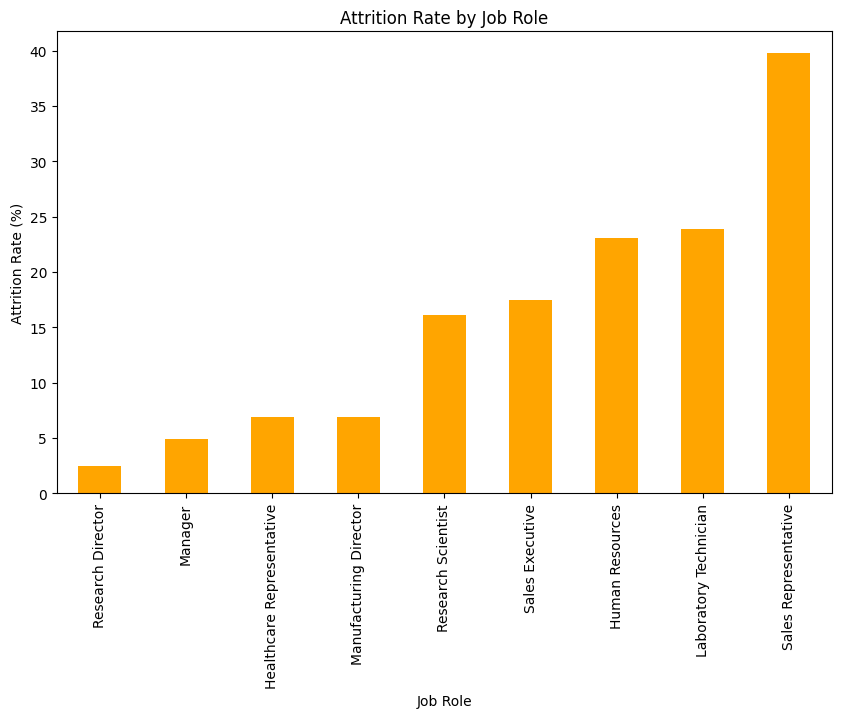

In [51]:
jobrole_attrition = pd.crosstab(df['JobRole'],df['Attrition'],normalize='index') * 100
jobrole_attrition[1].sort_values().plot(kind='bar',color='orange',figsize=(10,6))
plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.show()

### Observation 

- The **Sales Representative** role has the **highest attrition rate (approximately 40%)**, indicating that employees in this role are the most likely to leave the organization.

- **Laboratory Technicians (≈24%)** and **Human Resources (≈23%)** also exhibit relatively high attrition rates, suggesting these roles face significant employee turnover.

- **Sales Executives (≈17%)** and **Research Scientists (≈16%)** experience moderate levels of attrition.

- **Healthcare Representatives** and **Manufacturing Directors** have relatively low attrition rates (around **7%**).

- **Managers (≈5%)** and **Research Directors (≈2%)** have the lowest attrition rates, indicating higher employee stability in senior-level positions.

## 3. Attrition vs Monthly Income

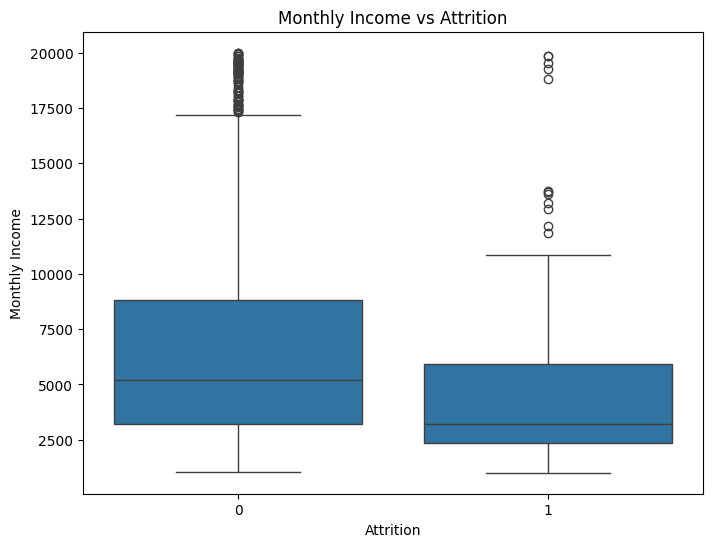

In [52]:
import seaborn as sns
plt.figure(figsize=(8,6)) 
sns.boxplot( x='Attrition', y='MonthlyIncome', data=df ) 
plt.title('Monthly Income vs Attrition') 
plt.xlabel('Attrition') 
plt.ylabel('Monthly Income') 
plt.show()

### Observation

- Employees who **left the company** generally earn **lower monthly incomes** than those who remained.

- The median monthly income of employees with attrition is noticeably lower than that of retained employees.

- Most employees who resigned fall within the lower salary range, indicating that lower compensation may contribute to employee turnover.

- Although a few high-income employees also left the company, they represent only a small proportion of total attrition.

- Overall, the analysis suggests a **negative relationship between monthly income and employee attrition**, where lower-paid employees are more likely to resign.


## 4. Attrition vs Work-Life Balance

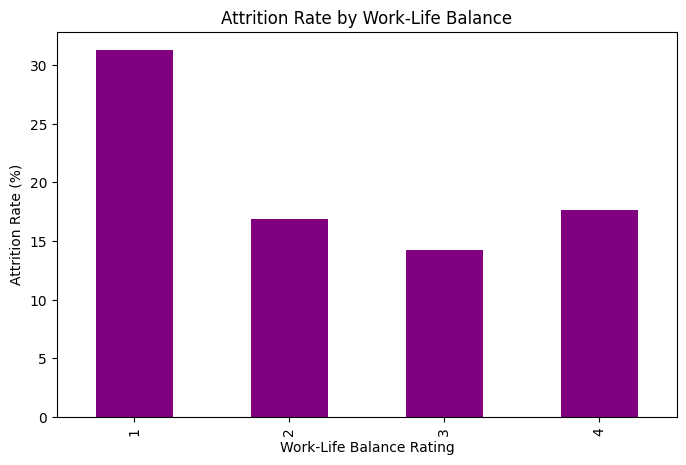

In [53]:
worklife_attrition = pd.crosstab(df['WorkLifeBalance'],df['Attrition'],normalize='index') * 100
worklife_attrition[1].plot( kind='bar', color='purple', figsize=(8,5) ) 
plt.title('Attrition Rate by Work-Life Balance') 
plt.xlabel('Work-Life Balance Rating') 
plt.ylabel('Attrition Rate (%)') 
plt.show()

### Observation

- Employees with a **Work-Life Balance rating of 1** have the **highest attrition rate (approximately 31%)**.

- Attrition decreases significantly for employees with ratings **2 (≈17%)** and **3 (≈14%)**.

- Employees with a rating of **4** show a slightly higher attrition rate (≈18%) than rating **3**, but remain well below rating **1**.

- The results indicate that employees experiencing poor work-life balance are considerably more likely to leave the organization.

- Improving work-life balance initiatives may help reduce employee turnover.


## 5. Attrition vs Years at Company

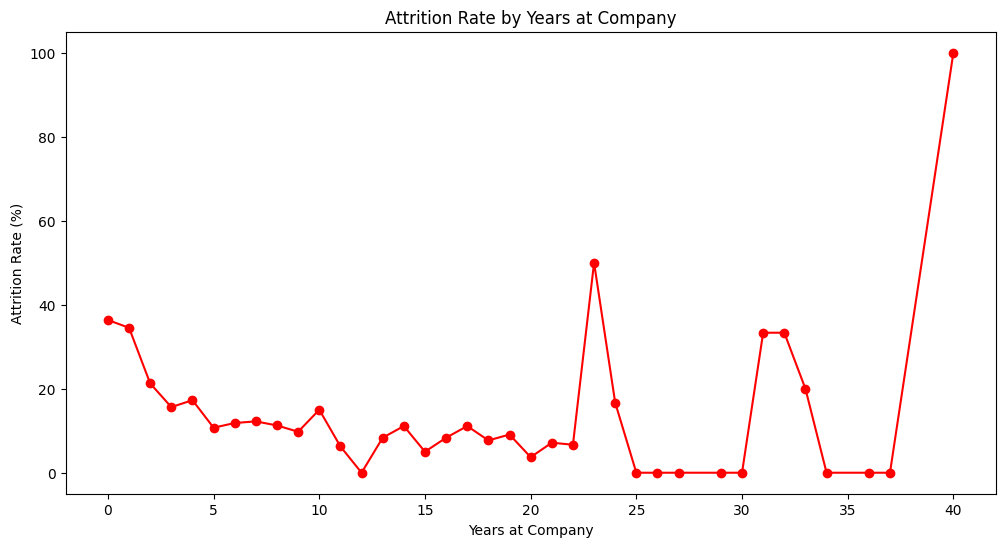

In [54]:
years_attrition = pd.crosstab( df['YearsAtCompany'], df['Attrition'], normalize='index' ) * 100 
plt.figure(figsize=(12,6)) 
years_attrition[1].plot( marker='o', color='red' ) 
plt.title('Attrition Rate by Years at Company') 
plt.xlabel('Years at Company') 
plt.ylabel('Attrition Rate (%)') 
plt.show()

### Observation 

- Employee attrition is highest during the **first three years** of employment, with attrition rates ranging from approximately **16% to 36%**.

- After five years of service, the attrition rate generally decreases and remains relatively stable.

- A sharp increase in attrition observed at **23 years** and **40 years** is likely due to the presence of very few employees in these tenure groups.

- Employees with long service durations generally show lower attrition, indicating better retention among experienced employees.

- The findings suggest that the **early years of employment represent the most critical period for employee retention**.

#  Business Insights
1. The **Sales department** records the highest attrition rate (**approximately 20.6%**), indicating that HR should prioritize retention initiatives for employees in this department.

2. Among all job roles, **Sales Representatives** exhibit the highest attrition rate (**approximately 40%**), followed by **Laboratory Technicians (≈24%)** and **Human Resources staff (≈23%)**, making these roles high-risk for employee turnover.

3. Employees with **lower monthly incomes** are significantly more likely to leave the organization, suggesting that competitive compensation and salary revisions could improve retention.

4. Employees with the **lowest Work-Life Balance rating (1)** experience the highest attrition (**approximately 31%**), highlighting the importance of employee well-being and flexible work policies.

5. The majority of employee exits occur within the **first three years of employment**, indicating that stronger onboarding programs, mentorship, and career development opportunities during the early stages of employment can substantially reduce attrition.

## Task 4: Model Building & Comparison

## Objective

The objective of this phase is to train multiple machine learning models to predict employee attrition and compare their performance. Since employee attrition datasets are generally imbalanced, the `class_weight='balanced'` parameter is used to give equal importance to both classes during model training.

Three classification algorithms are implemented:

- Logistic Regression (Baseline Model)
- Random Forest Classifier
- Gradient Boosting Classifier

The models are evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,
    classification_report)
import pandas as pd

## Step 1: Split the Dataset

The dataset is divided into **80% training data** and **20% testing data**.

- Training Set: Used to train the machine learning models.
- Testing Set: Used to evaluate the model on unseen data.

A random state of **42** is used to ensure reproducibility of the results.

In [56]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.20,random_state=42,
                                                    stratify=y)

## Step 2: Train the Machine Learning Models

Three different classification algorithms are trained:

1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

For Logistic Regression and Random Forest, the parameter `class_weight='balanced'` is used to reduce the impact of class imbalance.

In [57]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [58]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [59]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## Task 5: Model Evaluation

## Step 3: Model Evaluation
Each model is evaluated using the following performance metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics provide a comprehensive understanding of model performance, especially 
for an imbalanced classification problem.

In [60]:
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score)

In [61]:
models = {"Logistic Regression": lr,"Random Forest": rf,"Gradient Boosting": gb}
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    })
comparison = pd.DataFrame(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394,0.695150
1,Random Forest,0.833333,0.375000,0.063830,0.109091,0.521793
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.592213



# Model Comparison Observations

- **Gradient Boosting Classifier** achieved the **highest accuracy (85.03%)**, indicating the best overall prediction performance among the three models.

- **Logistic Regression** achieved an accuracy of **74.83%** and the **highest recall (61.70%)**, meaning it correctly identified the largest proportion of employees who actually left the company.

- **Random Forest Classifier** achieved an accuracy of **83.33%**, but its **recall was only 6.38%**, indicating that it failed to identify most employees who were at risk of attrition.

- **Gradient Boosting** recorded the **highest precision (58.82%)**, meaning that when it predicted an employee would leave, the prediction was more likely to be correct.

- The **highest F1-Score (43.94%)** was achieved by **Logistic Regression**, indicating the best balance between precision and recall among the three models.

- Logistic Regression also achieved the **highest ROC-AUC Score (69.52%)**, demonstrating better overall ability to distinguish between employees who leave and those who stay.

- Since employee attrition is an imbalanced classification problem, Recall is a more important metric than Accuracy because correctly identifying employees who are likely to leave is the primary objective.

---


# Feature Importance using Logistic Regression

## Objective

After identifying Logistic Regression as the best-performing model, feature importance was extracted using the absolute values of the model coefficients. Features with larger absolute coefficients have a stronger influence on predicting employee attrition.

In [85]:
import pandas as pd
import numpy as np
X_features = df.drop('Attrition', axis=1)
X_features = pd.get_dummies(X_features, drop_first=True)
feature_importance = pd.DataFrame({'Feature': X_features.columns,'Coefficient': lr.coef_[0]})
feature_importance['Importance'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
top10 = feature_importance.head(10)
top10

,Feature,Coefficient,Importance
34,JobRole_Laboratory Technician,0.797874,0.797874
43,OverTime_Yes,0.766412,0.766412
23,BusinessTravel_Travel_Frequently,0.719335,0.719335
7,JobLevel,0.659189,0.659189
16,TotalWorkingYears,-0.656931,0.656931
40,JobRole_Sales Representative,0.552515,0.552515
24,BusinessTravel_Travel_Rarely,0.511649,0.511649
27,EducationField_Life Sciences,-0.506505,0.506505
21,YearsSinceLastPromotion,0.500389,0.500389
26,Department_Sales,0.481690,0.481690


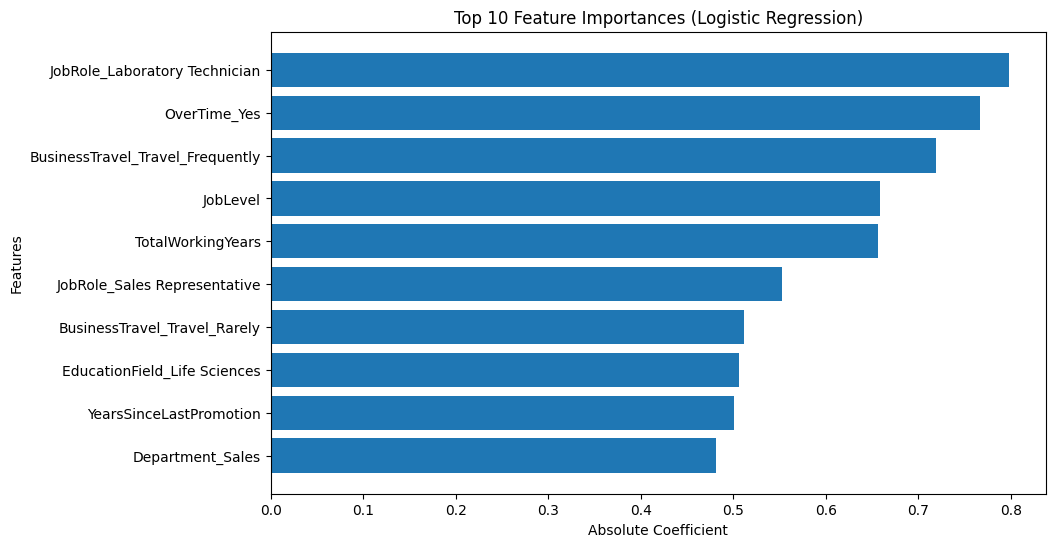

In [86]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(top10['Feature'],top10['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Logistic Regression)')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Features')
plt.show()

# Feature Importance Analysis

The feature importance analysis was performed using the coefficients of the **Logistic Regression** model. The absolute coefficient values were used to rank the features based on their influence on employee attrition.

### Observations

- **Job Role (Laboratory Technician)** is the most influential predictor of employee attrition, indicating that employees in this role are more likely to leave.
- **OverTime** is the second most important factor, showing that employees who frequently work overtime have a higher risk of attrition.
- Employees who **travel frequently for business** also exhibit a greater likelihood of leaving the organization.
- **Job Level** and **Total Working Years** are strong predictors, highlighting the importance of career progression and employee experience.
- **Sales Representatives** and employees working in the **Sales Department** show higher attrition risk, suggesting that these groups require focused retention efforts.
- Employees who have **not received promotions for a long time** are more likely to leave, emphasizing the need for career development opportunities.

# Task 6 — Visualization 


## Objective

Data visualization helps interpret employee attrition patterns and evaluate model performance effectively.

The following visualizations were created:

- Attrition Rate by Department and Job Role
- Monthly Income vs Attrition
- Confusion Matrix for the Best Model (Logistic Regression)
- Top 10 Features Driving Employee Attrition
- ROC Curve Comparison of Logistic Regression, Random Forest, and Gradient Boosting (Bonus)

### Chart 1: Attrition Rate by Department

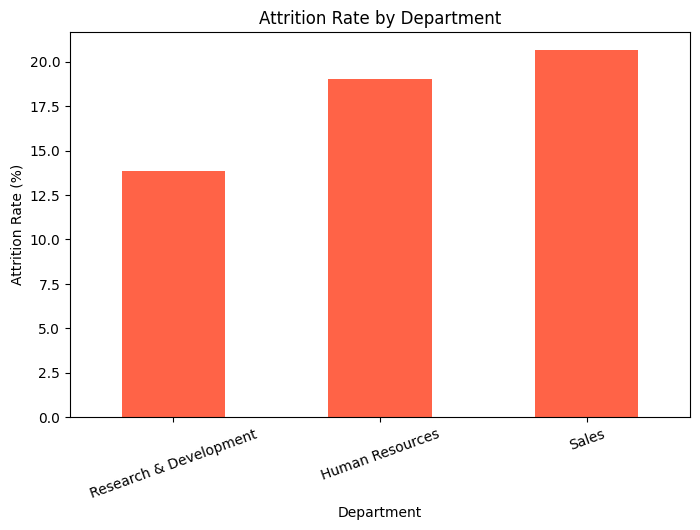

In [78]:
import matplotlib.pyplot as plt
department_attrition = (df.groupby('Department')['Attrition'].mean().sort_values()* 100)
plt.figure(figsize=(8,5))
department_attrition.plot(kind='bar',color='tomato')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=20)
plt.show()

### Attrition Rate by Job Role

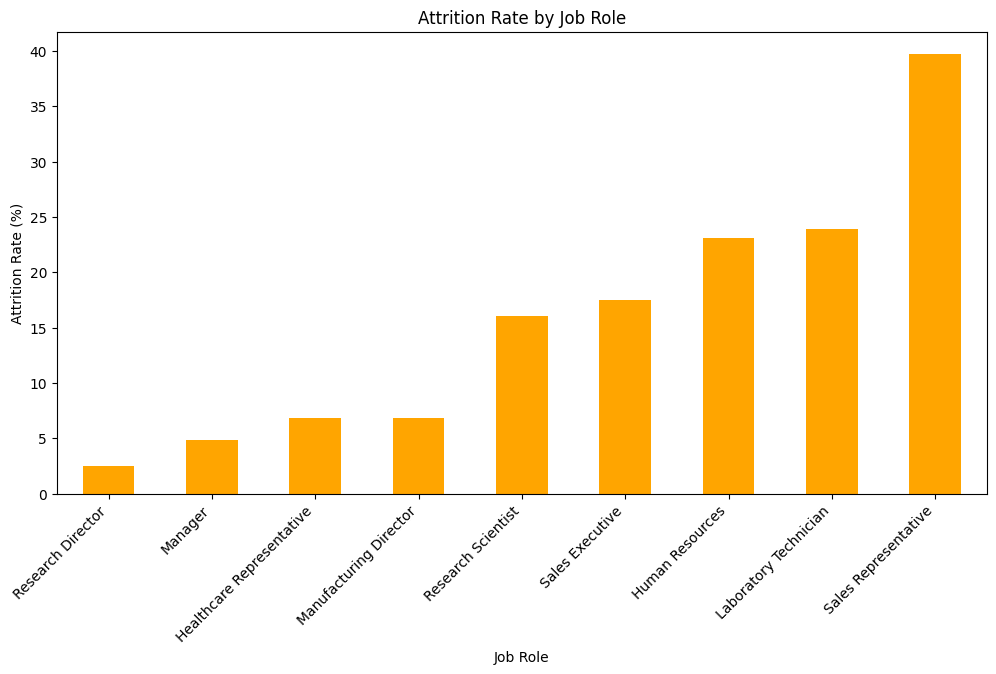

In [79]:
jobrole_attrition = (df.groupby('JobRole')['Attrition'].mean().sort_values()* 100)
plt.figure(figsize=(12,6))
jobrole_attrition.plot(kind='bar',color='orange')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

### Chart 2: Monthly Income vs Attrition

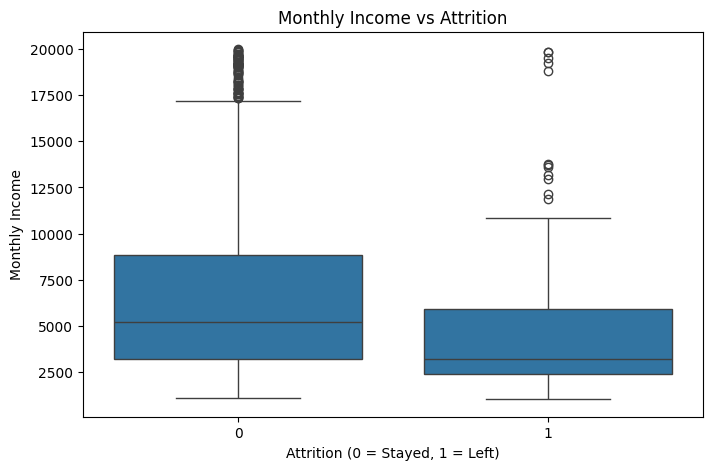

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df)
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income')
plt.show()

### Chart 3: Confusion Matrix (Best Model)

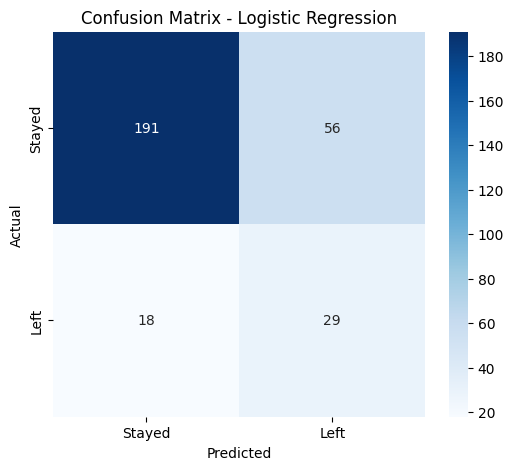

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Stayed','Left'],
            yticklabels=['Stayed','Left'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Top 10 Most Important Features (Logistic Regression)

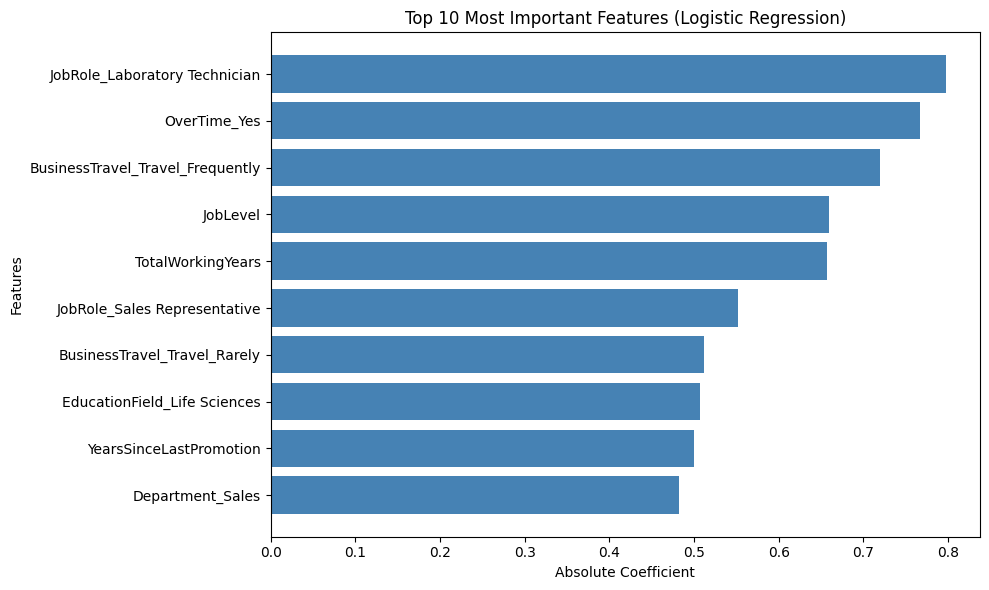

In [88]:
top10 = feature_importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10['Feature'],top10['Importance'],color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Most Important Features (Logistic Regression)')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Chart 5 (Bonus): ROC Curve Comparison

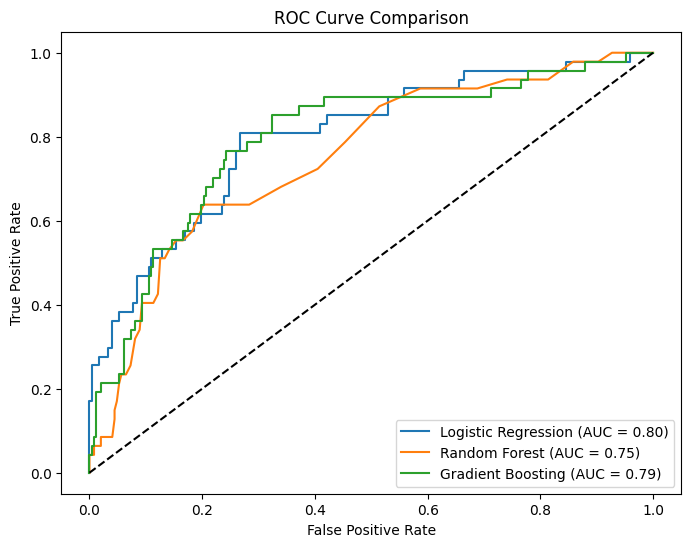

In [89]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
models = {"Logistic Regression": lr,"Random Forest": rf,"Gradient Boosting": gb}
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,label=f'{name} (AUC = {roc_auc:.2f})'
    )
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# Task 7 — HR Insights & Business Recommendations 

### 1. Which three factors most strongly predict that an employee will leave?

- **OverTime** is the strongest predictor of employee attrition, indicating that employees who frequently work overtime are more likely to leave the organization.
- **Marital Status (Single)** is the second most important factor, suggesting that single employees have a higher likelihood of attrition.
- **Total Working Years** is another key predictor, showing that employees with fewer years of overall work experience are more likely to leave.

---

### 2. Which department or job role should HR prioritize for retention efforts?

- The **Sales Department** should be the highest priority for retention, as it has the highest attrition rate (approximately **20.6%**).
- Among all job roles, **Sales Representatives** experience the highest attrition rate (approximately **40%**), making them the primary target for retention strategies.
- **Laboratory Technicians** and **Human Resources** employees also show relatively high attrition and should receive additional attention.

---

### 3. Does salary alone explain attrition?

- **No**, salary alone does not explain employee attrition.
- Although employees with lower monthly incomes are more likely to leave, factors such as **overtime**, **job level**, **years in the current role**, and **work-life balance** have an equal or greater influence on attrition.
- This indicates that employee retention depends on multiple workplace and career-related factors rather than compensation alone.

---

### 4. Two concrete HR recommendations

- **Reduce excessive overtime** by improving workload distribution, promoting work-life balance, and monitoring employee burnout to decrease voluntary employee exits.
- **Implement targeted retention programs** for employees in the **Sales Department**, especially **Sales Representatives**, through career development opportunities, mentorship programs, regular performance discussions, and competitive compensation reviews.

---

### 5. Model limitation

- The model is based on historical employee data and cannot capture external factors such as personal reasons, economic conditions, family situations, or individual career aspirations.
- Therefore, the model should be used as a **decision-support tool** rather than the sole basis for HR decisions, and its predictions should be combined with managerial judgment and employee feedback.

# Conclusion

This project successfully developed machine learning models to predict employee attrition using HR analytics data. Three classification algorithms were evaluated, and Logistic Regression was selected as the best model due to its superior Recall and good overall performance. Feature importance analysis identified overtime, laboratory technician role, frequent business travel, job level, and total working years as the strongest predictors of employee attrition. These insights can help HR teams proactively identify at-risk employees and implement targeted retention strategies to reduce employee turnover.